# Pancreatic Cancer Classification from Liquid Biopsy Platelet RNA-seq Data

This notebook presents the step-by-step solution for classifying pancreatic cancer based on gene expression data obtained from platelet RNA-seq.

Goal: Build a binary classifier distinguishing pancreatic cancer samples from controls (healthy + pancreatic diseases).

---

## 1. Loading the dataset

The data consists of two files:
- counts_pancreatic.csv - gene expression matrix (genes x samples), transposed so that rows correspond to samples and columns to genes.
- samples_pancreatic.xlsx - sample metadata (Group, Sex, Age, Stage, etc.).

Both files are joined on shared sample indices. The resulting Dataset object contains:
- X - DataFrame with gene expression values
- y - class label (Group)
- meta - full metadata
- age, sex - helper columns

In [1]:
# Install required packages
!pip install numpy pandas matplotlib scikit-learn seaborn openpyxl statsmodels plotly nbformat --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, balanced_accuracy_score, f1_score

from utilz.Dataset import load_dataset
from utilz.constans import HEALTHY, DISEASE, CANCER
from utilz.helpers import plot_split_balance, plot_pca, plot_group_overview
from utilz.preprocessing_utilz import (
    ConstantExpressionReductor, AnovaFdrReductor,
    MeanExpressionReductor,  WithinGroupVarianceReductor
)


meta_path = r"../data/samples_pancreatic.xlsx"
data_path = r"../data/counts_pancreatic.csv"

ds = load_dataset(data_path, meta_path, label_col="Group")

# Constants
TEST_SIZE = 0.2
VALID_SIZE = 0.2
# Preprocessing hyperparameters
MEAN_PERCENTILE = 5
ANOVA_FDR_THRESHOLD = 0.1
LOG2FC_THRESHOLD  = np.log2(1.5)


print(f"Number of samples: {ds.X.shape[0]}")
print(f"Number of genes:   {ds.X.shape[1]}")
print(f"\nOriginal class distribution:")
print(ds.y.value_counts())

[INFO] skipped 1973 probs due to missing metadata
Dropping inconsistent sample:
                        Sex   Age                Group   Institution  \
Vumc-ChronPan-29-TR1045   M  58.0  Pancreatic diseases  Institute 13   

                         Lib.size Stage RealLocation    Mode  CA125  \
Vumc-ChronPan-29-TR1045   1493422    IV         VUMC  Single    NaN   

                         Platelets Histology   Datasplit Gdansk_sample_name  \
Vumc-ChronPan-29-TR1045        NaN       NaN  Validation                NaN   

                        StageFull  LeukoMichal      PTPRC  
Vumc-ChronPan-29-TR1045        IV  7726.550165  97.092449  
Number of samples: 583
Number of genes:   42630

Original class distribution:
Group
Asymptomatic controls    410
Pancreatic cancer        124
Pancreatic diseases       49
Name: count, dtype: int64


### 1.1. Metadata overview

Overview of sample metadata - demographic and clinical variables that may be potential sources of bias.

In [3]:
ds.meta.head()

,Sex,Age,Group,Institution,Lib.size,Stage,RealLocation,Mode,CA125,Platelets,Histology,Datasplit,Gdansk_sample_name,StageFull,LeukoMichal,PTPRC
AMC-HD-001-TR1139,M,23.0,Asymptomatic controls,Institute 1,1065633,NaN,AMC,Single,NaN,NaN,NaN,Train,NaN,n.a.,9257.408507,167.036869
AMC-HD-002-TR1140,F,20.0,Asymptomatic controls,Institute 1,1126605,NaN,AMC,Single,NaN,NaN,NaN,Test,NaN,n.a.,7145.361506,47.043995
AMC-HD-003-TR1141,F,21.0,Asymptomatic controls,Institute 1,698667,NaN,AMC,Single,NaN,NaN,NaN,Validation,NaN,n.a.,10362.590476,88.740416
AMC-HD-004-TR1142,F,21.0,Asymptomatic controls,Institute 1,850492,NaN,AMC,Single,NaN,NaN,NaN,Train,NaN,n.a.,5721.394205,23.515800
AMC-HD-005-TR1143,F,21.0,Asymptomatic controls,Institute 1,824835,NaN,AMC,Single,NaN,NaN,NaN,Test,NaN,n.a.,14561.700219,58.193457


In [4]:

m_healthy = ds.y == HEALTHY
m_disease = ds.y == DISEASE
m_cancer  = ds.y == CANCER
m_hd      = m_healthy | m_disease

groups = {
    "Healthy":             m_healthy,
    "Other diseases":      m_disease,
    "Cancer":              m_cancer,
    "Healthy + other dis.":m_hd,
    "All":                 np.ones(len(ds.y), dtype=bool),
}

for name, mask in groups.items():
    meta = ds.meta[mask]
    age  = ds.age[mask]
    sex  = ds.sex[mask]
    n    = mask.sum()
    print(f"\n=== {name} (n={n}) ===")
    print(f"  Age: mean {age.mean():.1f} ± {age.std():.1f}, "
          f"median {age.median():.0f}, range {age.min():.0f}–{age.max():.0f}")
    for s, cnt in sex.value_counts().items():
        print(f"  Sex {s}: {cnt} ({cnt/n*100:.1f}%)")
    if name == "Cancer":
        for st, cnt in meta["Stage"].value_counts().sort_index().items():
            print(f"  Stage {st}: {cnt} ({cnt/n*100:.1f}%)")



=== Healthy (n=410) ===
  Age: mean 48.7 ± 15.8, median 51, range 18–86
  Sex F: 238 (58.0%)
  Sex M: 157 (38.3%)
  Sex n.a.: 15 (3.7%)

=== Other diseases (n=49) ===
  Age: mean 63.6 ± 10.8, median 65, range 39–82
  Sex F: 27 (55.1%)
  Sex M: 22 (44.9%)

=== Cancer (n=124) ===
  Age: mean 67.1 ± 9.8, median 68, range 42–87
  Sex M: 73 (58.9%)
  Sex F: 51 (41.1%)
  Stage I: 3 (2.4%)
  Stage II: 64 (51.6%)
  Stage III: 31 (25.0%)
  Stage IV: 25 (20.2%)

=== Healthy + other dis. (n=459) ===
  Age: mean 50.4 ± 16.0, median 53, range 18–86
  Sex F: 265 (57.7%)
  Sex M: 179 (39.0%)
  Sex n.a.: 15 (3.3%)

=== All (n=583) ===
  Age: mean 54.1 ± 16.4, median 56, range 18–87
  Sex F: 316 (54.2%)
  Sex M: 252 (43.2%)
  Sex n.a.: 15 (2.6%)


In [5]:

def make_group(mask):
    return (
        ds.y[mask].reset_index(drop=True),
        ds.sex[mask].reset_index(drop=True),
        ds.age[mask].reset_index(drop=True),
        ds.meta['Stage'][mask].reset_index(drop=True),
    )

m_healthy  = ds.y == HEALTHY
m_disease  = ds.y == DISEASE
m_cancer   = ds.y == CANCER
m_hd       = m_healthy | m_disease

splits_by_group = {
    'Healthy':          make_group(m_healthy),
    'Disease':          make_group(m_disease),
    'Cancer':           make_group(m_cancer),
    'Healthy+Disease':  make_group(m_hd),
}
plot_group_overview(
    splits_by_group,
    colors={
        'Healthy':         '#22c55e',
        'Disease':         '#f59e0b',
        'Cancer':          '#ef4444',
        'Healthy+Disease': '#6366f1',
    }
)


---

## 2. Label preparation - binary classification

The dataset contains three original classes:
- Asymptomatic control - healthy individuals
- Pancreatic diseases - other pancreatic conditions
- Pancreatic cancer - pancreatic cancer

The goal is to detect pancreatic cancer, so we merge Asymptomatic controls and Pancreatic diseases into a single control class. The problem becomes binary classification:

| New label | Original classes |
|---|---|
| 0 - Control | Asymptomatic controls + Pancreatic diseases |
| 1 - Cancer | Pancreatic cancer |

In [6]:
ds.y = ds.y.replace({DISEASE: HEALTHY})

print("Class distribution after merging:")
print(ds.y.value_counts())
print(f"\nClass ratio (control/cancer): {(ds.y == HEALTHY).sum() / (ds.y == CANCER).sum():.2f}")

Class distribution after merging:
Group
Asymptomatic controls    459
Pancreatic cancer        124
Name: count, dtype: int64

Class ratio (control/cancer): 3.70


In [7]:
# Encode labels numerically
le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(ds.y), index=ds.y.index)

print("Class mapping:")
print(f"{le.classes_[0]} -> {le.transform(le.classes_)[0]}")
print(f"{le.classes_[1]} -> {le.transform(le.classes_)[1]}")

print("Encoded label distribution:")
print(y_encoded.value_counts().sort_index())

Class mapping:
Asymptomatic controls -> 0
Pancreatic cancer -> 1
Encoded label distribution:
0    459
1    124
Name: count, dtype: int64


### 2.2. Expression matrix - basic statistics

In [8]:
"""
print(f"Shape (samples x genes): {ds.X.shape[0]} x {ds.X.shape[1]}")
print(f"Value range: [{ds.X.min().min():.2f}, {ds.X.max().max():.2f}]")
print(f"Missing values: {ds.X.isna().sum().sum()}")

ds.X.head(10).describe()
"""

'\nprint(f"Shape (samples x genes): {ds.X.shape[0]} x {ds.X.shape[1]}")\nprint(f"Value range: [{ds.X.min().min():.2f}, {ds.X.max().max():.2f}]")\nprint(f"Missing values: {ds.X.isna().sum().sum()}")\n\nds.X.head(10).describe()\n'

In [ ]:
from utilz.preprocessing_utilz import Log2FCReductor
from sklearn.feature_selection import f_classif

def create_volcano_plot(X, y, p_threshold=0.01, min_abs_log2fc=LOG2FC_THRESHOLD):
    reductor = Log2FCReductor(min_abs_log2fc=min_abs_log2fc).fit(X, y)
    log2fc = reductor.log2fc_.values
    deg_mask = X.columns.isin(reductor.selected_genes_)
    _, p_values = f_classif(X, y)
    neg_log10_p = -np.log10(p_values + 1e-300)
    sig_p = p_values < p_threshold
    up    = deg_mask & sig_p & (log2fc > 0)
    down  = deg_mask & sig_p & (log2fc < 0)

    colors = np.array(['grey'] * len(log2fc))
    colors[up]   = 'red'
    colors[down] = 'blue'

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(log2fc, neg_log10_p, c=colors, alpha=0.6, s=30)
    ax.axhline(-np.log10(p_threshold), color='black', linestyle='--', linewidth=1)
    ax.axvline( min_abs_log2fc, color='black', linestyle='--', linewidth=1)
    ax.axvline(-min_abs_log2fc, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('log2(FoldChange)', fontsize=12)
    ax.set_ylabel('-log10(p-value)', fontsize=12)
    ax.set_title(f'Volcano: |log2FC|>{min_abs_log2fc}, p<{p_threshold}  '
                 f'(up={int(up.sum())}, down={int(down.sum())})')

    return {
        'log2fc':      log2fc,
        'p_values':    p_values,
        'significant': up | down,
        'reductor':    reductor,
    }


create_volcano_plot(ds.X, y_encoded, p_threshold=0.01, min_abs_log2fc = LOG2FC_THRESHOLD)

---

## 3. Train / Test / Validation split

The data is split as follows:
- 60% - training set
- 20% - validation set (used for decision threshold tuning)
- 20% - test set (used for final model evaluation)

### Stratification

To avoid bias in the split, we apply combined stratification across four variables:
1. Class (y) - cancer vs. control
2. Sex
3. Age group (Age quantiled into 3 bins: young/mid/old)
4. Stage (grouped as I_II / III / IV)

This ensures that each subset maintains similar proportions of these variables, minimizing the risk of confounding.

In [10]:
X_train, X_test, X_valid, y_train, y_test, y_valid = (
    ds.get_train_test_valid_split(ds.X, y_encoded, test_size=TEST_SIZE, valid_size=VALID_SIZE)
)

print(f"Split sizes:")
print(f"  Train:      {X_train.shape[0]} samples ({X_train.shape[0]/ds.X.shape[0]*100:.1f}%)")
print(f"  Validation: {X_valid.shape[0]} samples ({X_valid.shape[0]/ds.X.shape[0]*100:.1f}%)")
print(f"  Test:       {X_test.shape[0]} samples ({X_test.shape[0]/ds.X.shape[0]*100:.1f}%)")
print(f"  Total:      {X_train.shape[0] + X_valid.shape[0] + X_test.shape[0]} samples")
print(f"\nNumber of features: {X_train.shape[1]}")

[INFO] 7 samples with unique strata added to train set
[INFO] 4 samples with unique strata (2nd split) added to train set

[ASSERTION PASSED] No leakage detected between splits.
Split sizes:
  Train:      356 samples (61.1%)
  Validation: 114 samples (19.6%)
  Test:       113 samples (19.4%)
  Total:      583 samples

Number of features: 42630


### 3.1. Split balance overview

Class counts, proportions, and demographic distributions across train/test/validation splits.

In [11]:
split_summary = pd.DataFrame({
    'Train': y_train.value_counts().sort_index(),
    'Validation': y_valid.value_counts().sort_index(),
    'Test': y_test.value_counts().sort_index(),
})
split_summary.index = [le.inverse_transform([i])[0] for i in split_summary.index]

split_pct = pd.DataFrame({
    'Train (%)': y_train.value_counts(normalize=True).sort_index() * 100,
    'Validation (%)': y_valid.value_counts(normalize=True).sort_index() * 100,
    'Test (%)': y_test.value_counts(normalize=True).sort_index() * 100,
})
split_pct.index = split_summary.index
combined = pd.DataFrame({
    'Train': split_summary['Train'].astype(str) + ' (' + split_pct['Train (%)'].round(1).astype(str) + '%)',
    'Validation': split_summary['Validation'].astype(str) + ' (' + split_pct['Validation (%)'].round(1).astype(str) + '%)',
    'Test': split_summary['Test'].astype(str) + ' (' + split_pct['Test (%)'].round(1).astype(str) + '%)',
})

totals = split_summary.sum()
combined.loc['Total'] = [str(totals['Train']), str(totals['Validation']), str(totals['Test'])]

display(combined)

stage_col = ds.meta['Stage'].copy()
stage_col = stage_col.replace({'I': 'I-II', 'II': 'I-II'})

plot_split_balance({
    'Train': (y_train, ds.sex.loc[X_train.index], ds.age.loc[X_train.index], ds.meta["Stage"].loc[X_train.index].replace({'I': 'I-II', 'II': 'I-II'})),
    'Test':  (y_test,  ds.sex.loc[X_test.index],  ds.age.loc[X_test.index],  ds.meta["Stage"].loc[X_test.index].replace({'I': 'I-II', 'II': 'I-II'})),
    'Valid': (y_valid, ds.sex.loc[X_valid.index], ds.age.loc[X_valid.index], ds.meta["Stage"].loc[X_valid.index].replace({'I': 'I-II', 'II': 'I-II'})),
})

,Train,Validation,Test
Asymptomatic controls,275 (77.2%),92 (80.7%),92 (81.4%)
Pancreatic cancer,81 (22.8%),22 (19.3%),21 (18.6%)
Total,356,114,113


### 3.2. Data leakage check

Verify that no sample appears in more than one split.

In [12]:
train_test_overlap = X_train.index.intersection(X_test.index)
train_valid_overlap = X_train.index.intersection(X_valid.index)
test_valid_overlap = X_test.index.intersection(X_valid.index)

print(f"Overlap Train - Test:       {len(train_test_overlap)}")
print(f"Overlap Train - Validation: {len(train_valid_overlap)}")
print(f"Overlap Test  - Validation: {len(test_valid_overlap)}")

assert len(train_test_overlap) + len(train_valid_overlap) + len(test_valid_overlap) == 0, \
    "Data leakage"
print("\nNo data leakage - all splits are disjoint.")

Overlap Train - Test:       0
Overlap Train - Validation: 0
Overlap Test  - Validation: 0

No data leakage - all splits are disjoint.


---

## 4. Preprocessing - feature reduction pipeline

The preprocessing pipeline reduces 42,630 genes to a manageable set by sequentially applying:

| Step | Reducer                                    | Purpose |
|---|--------------------------------------------|---|
| 1 | **ConstantExpressionReductor**             | Remove genes with zero variance (single unique value) |
| 2 | **AnovaReductor** (percentile=60)          | Keep top 30% genes by ANOVA F-score vs. class label |
| 3 | **MeanExpressionReductor** (percentile=20) | Remove bottom 10% by mean expression level |
| 4 | **AgeBiasTransformer**                        | Remove genes significantly correlated with age (OLS + FDR-BH) |
| 5 | **SexBiasReductor**                        | Remove genes significantly correlated with sex (OLS + FDR-BH) |
| 6 | **StandardScaler**                         | Zero-mean, unit-variance normalization |

All reductors are fit on the training set only and applied to validation/test sets to prevent data leakage.

### 4.1. Pipeline definition and gene reduction summary

In [13]:
from utilz.multi_residual_bootstrap import MultiCovariateResidualBootstrapTransformer
from utilz.preprocessing_utilz import SexResidualBootstrapTransformer, AgeResidualBootstrapTransformer
from utilz.multi_residual_bootstrap import (
    MultiCovariateResidualBootstrapTransformer, build_covariates,
)

cov = build_covariates(ds.meta)
sex_numeric = ds.sex.map({"F": 0, "M": 1})


pipeline = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    ('multi_resid', MultiCovariateResidualBootstrapTransformer(
    covariates=cov, labels=y_train,
    n_bootstrap=500, fdr_alpha=0.05, min_r2=0.05, cv_threshold_pct=30.0,
    )),
    ('AnovaFDRReductor', AnovaFdrReductor(alpha=ANOVA_FDR_THRESHOLD)),
    ('Log2FCReductor', Log2FCReductor(min_abs_log2fc = LOG2FC_THRESHOLD)),
    ('WithinGroupVarianceReductor', WithinGroupVarianceReductor(alpha=0.05)),
    ('scaler', StandardScaler()),
])

step_names = []
step_counts = []
step_genes = {}

X_current = X_train.copy()
step_names.append("Raw input")
step_counts.append(X_current.shape[1])
step_genes["Raw input"] = list(X_current.columns)

for name, transformer in pipeline.steps:
    if name == 'scaler':
        transformer.fit(X_current)
        X_current = pd.DataFrame(
            transformer.transform(X_current),
            columns=X_current.columns, index=X_current.index
        )
    else:
        transformer.fit(X_current, y_train)
        X_current = transformer.transform(X_current)
    step_names.append(name)
    step_counts.append(X_current.shape[1])
    if name != 'scaler':
        step_genes[name] = list(transformer.selected_genes_)

# Summary table
reduction_df = pd.DataFrame({
    'Step': step_names,
    'Genes remaining': step_counts,
    'Genes removed': [0] + [step_counts[i] - step_counts[i+1] for i in range(len(step_counts)-1)],
})
reduction_df['% of original'] = (reduction_df['Genes remaining'] / step_counts[0] * 100).round(1)

print(f"Preprocessing pipeline: {step_counts[0]} → {step_counts[-1]} genes\n")
reduction_df

data shape after ConstantExpressionReductor:  (356, 30588)
  [MultiCovariateResidualBootstrapTransformer] fit OLS on 260 probs for 2284 stable genes (3 covariates)
data shape after MultiCovariateResidualBootstrapTransformer: (356, 30588)
data shape after AnovaFdrReductor:  (356, 4361)
data shape after Log2FCReductor:  (356, 510)
data shape after WithinGroupVarianceReductor: (356, 305) sigma^2_ref = 2.118, alpha = 0.05)
Preprocessing pipeline: 42630 → 305 genes



,Step,Genes remaining,Genes removed,% of original
0,Raw input,42630,0,100.0
1,ConstantExpressionReductor,30588,12042,71.8
2,multi_resid,30588,0,71.8
3,AnovaFDRReductor,4361,26227,10.2
4,Log2FCReductor,510,3851,1.2
5,WithinGroupVarianceReductor,305,205,0.7
6,scaler,305,0,0.7


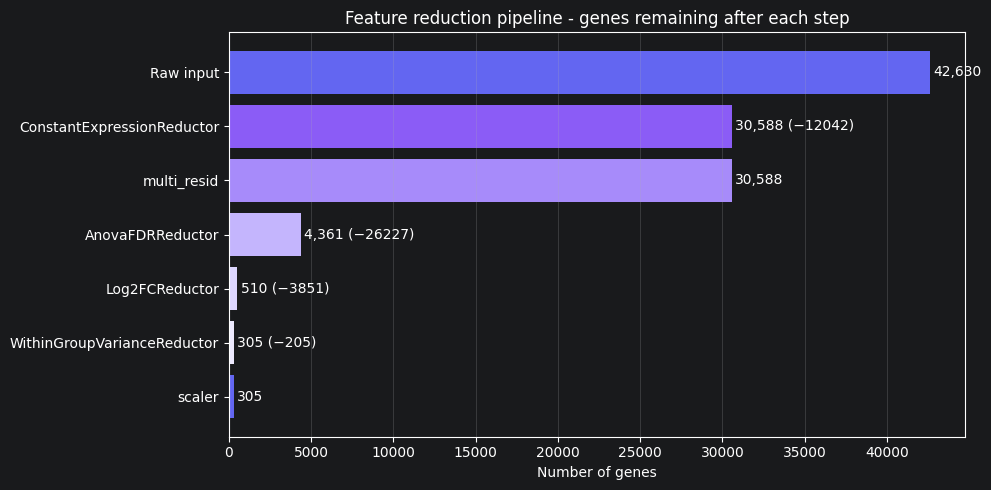

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#6366f1', '#8b5cf6', '#a78bfa', '#c4b5fd', '#ddd6fe', '#ede9fe']
bars = ax.barh(range(len(step_names)), step_counts, color=colors[:len(step_names)])

for i, (count, name) in enumerate(zip(step_counts, step_names)):
    removed = f" (−{step_counts[i-1] - count})" if i > 0 and step_counts[i-1] != count else ""
    ax.text(count + 200, i, f"{count:,}{removed}", va='center', fontsize=10)

ax.set_yticks(range(len(step_names)))
ax.set_yticklabels(step_names)
ax.invert_yaxis()
ax.set_xlabel("Number of genes")
ax.set_title("Feature reduction pipeline - genes remaining after each step")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2. PCA before and after preprocessing

PCA visualization on the test set

=== PCA BEFORE preprocessing ===


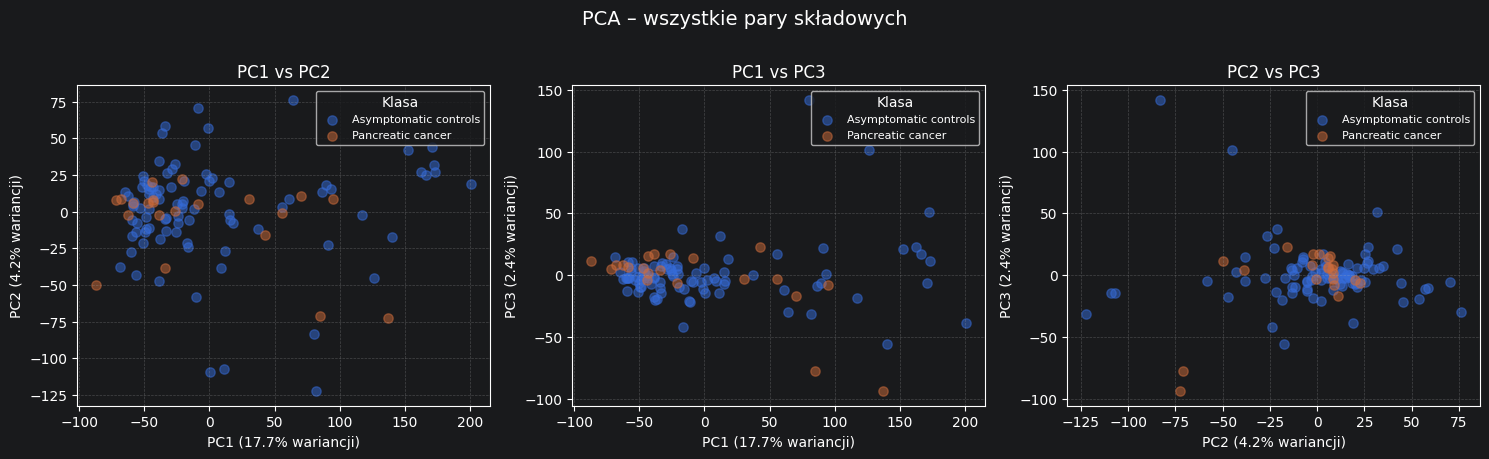

data shape after ConstantExpressionReductor:  (113, 30588)
data shape after MultiCovariateResidualBootstrapTransformer: (113, 30588)
data shape after AnovaFdrReductor:  (113, 4361)
data shape after Log2FCReductor:  (113, 510)
data shape after WithinGroupVarianceReductor: (113, 305) sigma^2_ref = 2.118, alpha = 0.05)

=== PCA AFTER preprocessing (305 genes) ===


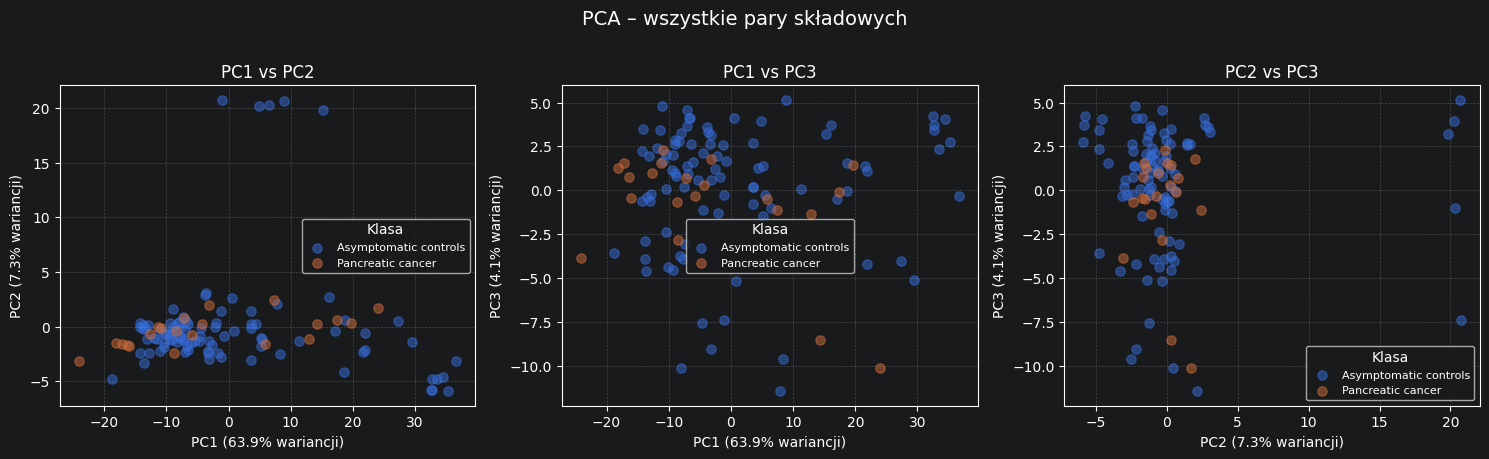

In [15]:
num_pca_components =3

print("=== PCA BEFORE preprocessing ===")
plot_pca(X_test, y_test, num_pca_components, le)

X_test_filtered = X_test.copy()
for name, transformer in pipeline.steps:
    if name == 'scaler':
        break
    X_test_filtered = transformer.transform(X_test_filtered)

print(f"\n=== PCA AFTER preprocessing ({X_test_filtered.shape[1]} genes) ===")
plot_pca(X_test_filtered, y_test, num_pca_components, le)

### 4.3. ANOVA filtering effect

The AnovaReductor keeps the top genes by ANOVA F-score (within-class / between-class variances).

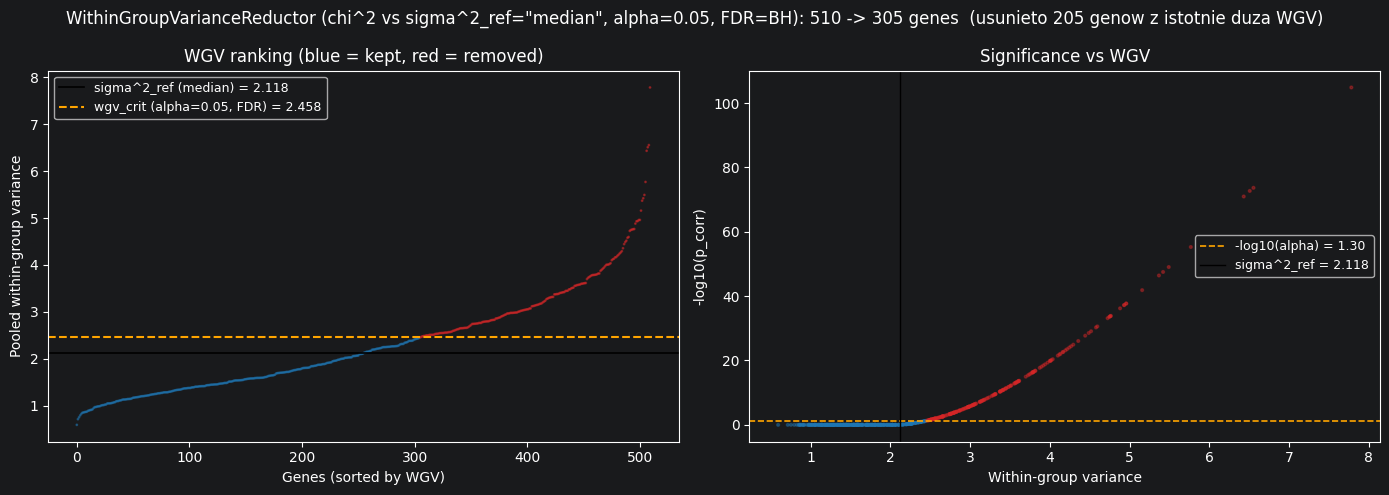

In [16]:
wgv_red = pipeline.named_steps['WithinGroupVarianceReductor']

wgv          = wgv_red.wgv_
p_corr       = wgv_red.pvalues_corrected_
sigma2_ref   = wgv_red.sigma2_ref_
kept_genes   = wgv_red.selected_genes_
kept_mask    = wgv.index.isin(kept_genes)
removed_wgv = wgv[~kept_mask]
wgv_crit = removed_wgv.min() if len(removed_wgv) else np.nan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sorted_idx = np.argsort(wgv.values)
sorted_wgv = wgv.values[sorted_idx]
sorted_kept = kept_mask[sorted_idx]
colors = np.where(sorted_kept, 'tab:blue', 'tab:red')
ax.scatter(np.arange(len(sorted_wgv)), sorted_wgv, c=colors, s=1, alpha=0.5)
ax.axhline(sigma2_ref, color='black', ls='-', lw=1.2,
           label=f'sigma^2_ref (median) = {sigma2_ref:.4g}')
if np.isfinite(wgv_crit):
    ax.axhline(wgv_crit, color='orange', ls='--', lw=1.5,
               label=f'wgv_crit (alpha={wgv_red.alpha}, FDR) = {wgv_crit:.4g}')
ax.set(xlabel='Genes (sorted by WGV)',
       ylabel='Pooled within-group variance',
       title='WGV ranking (blue = kept, red = removed)')
ax.legend(fontsize=9)

# panel 2: volcano-style WGV vs -log10(p_corr)
ax = axes[1]
neg_log10_p = -np.log10(p_corr.values + 1e-300)
colors2 = np.where(kept_mask, 'tab:blue', 'tab:red')
ax.scatter(wgv.values, neg_log10_p, c=colors2, s=4, alpha=0.4)
ax.axhline(-np.log10(wgv_red.alpha), color='orange', ls='--', lw=1.2,
           label=f'-log10(alpha) = {-np.log10(wgv_red.alpha):.2f}')
ax.axvline(sigma2_ref, color='black', ls='-', lw=1.0,
           label=f'sigma^2_ref = {sigma2_ref:.4g}')
ax.set(xlabel='Within-group variance', ylabel='-log10(p_corr)',
       title='Significance vs WGV')
ax.legend(fontsize=9)

plt.suptitle(
    f'WithinGroupVarianceReductor (chi^2 vs sigma^2_ref="median", '
    f'alpha={wgv_red.alpha}, FDR=BH): '
    f'{len(wgv)} -> {kept_mask.sum()} genes  '
    f'(usunieto {(~kept_mask).sum()} genow z istotnie duza WGV)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

### 4.4. Age bias removal - validation

To verify that the AgeBiasTransformer effectively removes age-correlated signal, we train a simple age prediction model (Lasso regression) on healthy controls before and after debiasing. A successful reductor should **decrease** the model's ability to predict age from gene expression, confirming that confounding age signal has been removed.

data shape after ConstantExpressionReductor:  (343, 30272)
data shape after ConstantExpressionReductor:  (108, 30272)
data shape after ConstantExpressionReductor:  (108, 30272)
data shape after ConstantExpressionReductor:  (343, 30272)
  [MultiCovariateResidualBootstrapTransformer] fit OLS on 260 probs for 2222 stable genes (3 covariates)
data shape after MultiCovariateResidualBootstrapTransformer: (343, 30272)
data shape after ConstantExpressionReductor:  (108, 30272)
data shape after MultiCovariateResidualBootstrapTransformer: (108, 30272)
data shape after ConstantExpressionReductor:  (108, 30272)
data shape after MultiCovariateResidualBootstrapTransformer: (108, 30272)
n_samples (healthy z age) = 343
p_before  = 30272  ratio n/p = 0.0

Before AgeBiasTransformer (30272 genes):  MAE=11.11  R^2=+0.2958
After  AgeBiasTransformer (30272 genes):  MAE= 9.71  R^2=+0.4585
--- BASELINE (predict mean = 53.9):    MAE=13.52  R^2= 0.0000


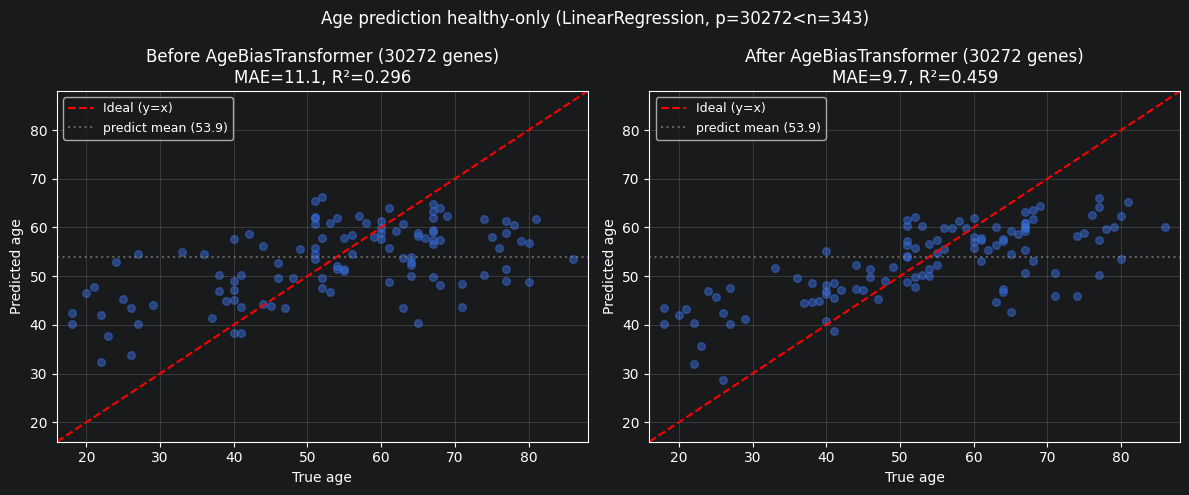

In [17]:
from utilz.preprocessing_utilz import AgeResidualBootstrapTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt


age = ds.age.dropna().astype(int)
tr_idx = X_train.index.intersection(age.index)
te_idx = X_test.index.intersection(age.index)

pipe_without_age = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    #('MeanExpressionReductor',     MeanExpressionReductor(percentile=TIGHT_MEAN_PERCENTILE)),
    ('scaler',                     StandardScaler()),
    ('model',                      LinearRegression()),
])

pipe_with_age = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    #('MeanExpressionReductor',     MeanExpressionReductor(percentile=TIGHT_MEAN_PERCENTILE)),
    ('multi_resid', MultiCovariateResidualBootstrapTransformer(
        covariates=cov, labels=y_train,
        n_bootstrap=1000, fdr_alpha=0.1, min_r2=0.05, cv_threshold_pct=30.0,
    )),
    ('scaler',                     StandardScaler()),
    ('model',                      LinearRegression()),
])

pipe_without_age.fit(X_train.loc[tr_idx], age.loc[tr_idx])
pred_before = pipe_without_age.predict(X_test.loc[te_idx])
n_before    = pipe_without_age[:-1].transform(X_test.loc[te_idx]).shape[1]
mae_before  = mean_absolute_error(age.loc[te_idx], pred_before)
r2_before   = r2_score(age.loc[te_idx], pred_before)

pipe_with_age.fit(X_train.loc[tr_idx], age.loc[tr_idx])
pred_after  = pipe_with_age.predict(X_test.loc[te_idx])
n_after     = pipe_with_age[:-1].transform(X_test.loc[te_idx]).shape[1]
mae_after   = mean_absolute_error(age.loc[te_idx], pred_after)
r2_after    = r2_score(age.loc[te_idx], pred_after)

mean_age  = age.loc[tr_idx].mean()
mae_mean  = mean_absolute_error(age.loc[te_idx], np.full(len(te_idx), mean_age))

n_samples = len(tr_idx)
print(f"n_samples (healthy z age) = {n_samples}")
print(f"p_before  = {n_before}  ratio n/p = {n_samples/n_before:.1f}")
print()
print(f"Before AgeBiasTransformer ({n_before:>4} genes):  MAE={mae_before:5.2f}  R^2={r2_before:+.4f}")
print(f"After  AgeBiasTransformer ({n_after:>4} genes):  MAE={mae_after:5.2f}  R^2={r2_after:+.4f}")
print(f"--- BASELINE (predict mean = {mean_age:.1f}):    MAE={mae_mean:5.2f}  R^2= 0.0000")

# plot bez zmian
y_true = age.loc[te_idx]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, n, mae, r2, title in [
    (ax1, pred_before, n_before, mae_before, r2_before, "Before AgeBiasTransformer"),
    (ax2, pred_after,  n_after,  mae_after,  r2_after,  "After AgeBiasTransformer"),
]:
    lim = [min(y_true.min(), pred.min()) - 2, max(y_true.max(), pred.max()) + 2]
    ax.scatter(y_true, pred, alpha=0.5, s=30)
    ax.plot(lim, lim, 'r--', label='Ideal (y=x)')
    ax.axhline(mean_age, color='gray', ls=':', alpha=0.7,
               label=f'predict mean ({mean_age:.1f})')
    ax.set(xlim=lim, ylim=lim, xlabel="True age", ylabel="Predicted age",
           title=f"{title} ({n} genes)\nMAE={mae:.1f}, R²={r2:.3f}")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle(f"Age prediction healthy-only (LinearRegression, p={n_before}<n={n_samples})", fontsize=12)
plt.tight_layout()
plt.show()

### 4.5. Sex bias removal - validation

Analogous test for SexBiasReductor: we train a sex classifier (Logistic Regression) on healthy controls before and after removing sex-correlated genes. A successful reductor should decrease sex classification accuracy.

In [18]:
# Two pipelines: with and without SexBiasReductor
pipe_without_sex = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    #('MeanExpressionReductor', MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1500, class_weight='balanced')),
])

pipe_with_sex = Pipeline([
    ('ConstantExpressionReductor', ConstantExpressionReductor()),
    #('MeanExpressionReductor', MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
        ('multi_resid', MultiCovariateResidualBootstrapTransformer(
        covariates=cov, labels=y_train,
        n_bootstrap=1000, fdr_alpha=0.1, min_r2=0.05, cv_threshold_pct=30.0,
    )),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1500, class_weight='balanced')),
])

sex = sex_numeric.dropna().astype(int)
tr_idx_s = X_train.index.intersection(sex.index)
te_idx_s = X_test.index.intersection(sex.index)

# --- Before SexBiasReductor ---
pipe_without_sex.fit(X_train.loc[tr_idx_s], sex.loc[tr_idx_s])
pred_before_sex = pipe_without_sex.predict(X_test.loc[te_idx_s])
n_before_sex = pipe_without_sex[:-1].transform(X_test.loc[te_idx_s]).shape[1]
ba_before = balanced_accuracy_score(sex.loc[te_idx_s], pred_before_sex)
f1_before = f1_score(sex.loc[te_idx_s], pred_before_sex, average='weighted')

# --- After SexBiasReductor ---
pipe_with_sex.fit(X_train.loc[tr_idx_s], sex.loc[tr_idx_s])
pred_after_sex = pipe_with_sex.predict(X_test.loc[te_idx_s])
n_after_sex = pipe_with_sex[:-1].transform(X_test.loc[te_idx_s]).shape[1]
ba_after = balanced_accuracy_score(sex.loc[te_idx_s], pred_after_sex)
f1_after = f1_score(sex.loc[te_idx_s], pred_after_sex, average='weighted')

print("Sex classification (test set):")
print("-" * 55)
print(f"Before SexBiasReductor ({n_before_sex} genes):")
print(f"  Balanced Accuracy: {ba_before:.3f},  F1: {f1_before:.3f}")
print(f"After SexBiasReductor  ({n_after_sex} genes):")
print(f"  Balanced Accuracy: {ba_after:.3f},  F1: {f1_after:.3f}")

data shape after ConstantExpressionReductor:  (346, 30486)
data shape after ConstantExpressionReductor:  (110, 30486)
data shape after ConstantExpressionReductor:  (110, 30486)
data shape after ConstantExpressionReductor:  (346, 30486)
  [MultiCovariateResidualBootstrapTransformer] fit OLS on 260 probs for 2222 stable genes (3 covariates)
data shape after MultiCovariateResidualBootstrapTransformer: (346, 30486)
data shape after ConstantExpressionReductor:  (110, 30486)
data shape after MultiCovariateResidualBootstrapTransformer: (110, 30486)
data shape after ConstantExpressionReductor:  (110, 30486)
data shape after MultiCovariateResidualBootstrapTransformer: (110, 30486)
Sex classification (test set):
-------------------------------------------------------
Before SexBiasReductor (30486 genes):
  Balanced Accuracy: 0.818,  F1: 0.819
After SexBiasReductor  (30486 genes):
  Balanced Accuracy: 0.734,  F1: 0.743
